<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 55px 45px;
            border-radius: 24px;
            text-align: center;
            border: 2px solid #7c3aed;
            box-shadow: 0px 0px 25px rgba(124,58,237,0.45);
            width: 78%;
            margin: auto;">

<h1 style="color:#c084fc; font-size:3em; font-weight:900; margin-bottom:8px; letter-spacing:2px;">
    🩺 Advanced Healthcare Analytics
</h1>

<h2 style="color:#e879f9; font-size:1.9em; font-weight:700; margin-bottom:10px;">
    Diabetes Risk Factor Analysis
</h2>

<h3 style="color:#a5b4fc; font-size:1.35em; font-weight:400; margin-bottom:22px;">
    Exploratory Data Analysis · Statistical Analysis · Risk Profiling · Healthcare Insights
</h3>

<hr style="border:1px solid #7c3aed; margin:20px auto; width:65%;">

<p style="color:#cbd5e1; font-size:1.08em; line-height:2.1em;">
    📌 <b>Project :</b> ShadowFox Internship — Task 3 (Advanced Level) <br>
    📦 <b>Dataset :</b> Pima Indians Diabetes Dataset (UCI / Kaggle) <br>
    🛠️ <b>Tools :</b> Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy · Jupyter Notebook <br>
    🎯 <b>Research Goal :</b> Identify key healthcare indicators contributing to diabetes risk <br>
    📊 <b>Analysis Focus :</b> Glucose · BMI · Age · Insulin · Blood Pressure · Risk Correlation
</p>

<hr style="border:1px solid #7c3aed; margin:20px auto; width:50%;">

<p style="color:#94a3b8; font-size:1.02em; margin-top:15px;">
    👩‍💻 Prepared By: <b>Tuba Mariyam Khateeb</b>
</p>

</div>

# Introduction

Diabetes is one of the most significant chronic health conditions affecting millions of individuals worldwide. It develops when the body struggles to regulate blood glucose levels, leading to long-term health complications if left unmanaged.

Healthcare analytics plays an important role in understanding disease patterns, identifying major risk factors, and supporting preventive healthcare strategies. By analyzing patient health indicators such as glucose level, body mass index (BMI), insulin level, age, and blood pressure, meaningful insights can be derived regarding diabetes risk.

This project presents an advanced healthcare analytics approach to explore diabetes-related health patterns and determine which medical indicators contribute most significantly to diabetes occurrence.

# Project Objectives

The primary objectives of this study are:

- To explore healthcare-related patient data and understand its structure
- To identify key health indicators contributing to diabetes risk
- To analyze relationships among medical variables
- To investigate patient health patterns across age and medical conditions
- To utilize advanced visualization techniques for healthcare insights
- To derive preventive healthcare recommendations based on statistical evidence

# Research Questions

This study investigates the following research questions:

### Main Research Question

**Which health indicators contribute most significantly to diabetes risk?**

### Supporting Research Questions

1. How does glucose level affect diabetes probability?

2. Is Body Mass Index (BMI) strongly associated with diabetes occurrence?

3. Does age significantly influence diabetes prevalence?

4. How does blood pressure relate to diabetes risk?

5. What relationships exist among patient health indicators?

6. Which variables show the strongest correlation with diabetes outcome?

7. Which patient groups demonstrate higher diabetes vulnerability?

8. Can statistical patterns support preventive healthcare strategies?

9. What healthcare insights can be derived from patient trends?

10. How can healthcare institutions use these findings to improve preventive screening?

In [22]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("../data/diabetes.csv")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

# First rows
print("\nFirst 5 Rows:")
print(df.head())

# Shape
print("\nDataset Shape:")
print(df.shape)

# Columns
print("\nColumn Names:")
print(df.columns)

# Dataset Info
print("\nDataset Information:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

DATASET INFORMATION

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIn

In [23]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Columns where 0 is unrealistic
columns_to_fix = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace 0 with NaN
for column in columns_to_fix:
    df[column] = df[column].replace(0, np.nan)

print("\nZero values replaced with NaN successfully!")

# Missing values check
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

DATA CLEANING

Zero values replaced with NaN successfully!

Missing Values After Cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [24]:
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Fill missing values using median
for column in columns_to_fix:
    df[column].fillna(
        df[column].median(),
        inplace=True
    )

print("\nMissing values handled successfully!")

print("\nFinal Missing Values:")
print(df.isnull().sum())

HANDLING MISSING VALUES

Missing values handled successfully!

Final Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [25]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Age Group
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 60, 100],
    labels=[
        '20-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

# BMI Category
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

print("\nFeature Engineering Completed!")

print(df.head())

FEATURE ENGINEERING

Feature Engineering Completed!
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome Age_Group BMI_Category  
0                     0.627   50        1     41-50        Obese  
1                     0.351   31        0     31-40   Overweight  
2                     0.672   32        1     31-40       Normal  
3                     0.167   21        0     20-30   Overweight  
4                     2.288   33        1     31-40        Obese  


In [26]:
print("="*60)
print("UPDATED DATASET")
print("="*60)

print(df.head())

print("\nDataset Shape:")
print(df.shape)

UPDATED DATASET
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome Age_Group BMI_Category  
0                     0.627   50        1     41-50        Obese  
1                     0.351   31        0     31-40   Overweight  
2                     0.672   32        1     31-40       Normal  
3                     0.167   21        0     20-30   Overweight  
4                     2.288   33        1     31-40        Obese  

Dataset Shape:
(768, 11)


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better graph styling
sns.set_style("whitegrid")

# Bigger graphs
plt.rcParams['figure.figsize'] = (10,6)

# Visualization 1: Diabetes Outcome Distribution

This visualization helps understand the proportion of diabetic and non-diabetic patients within the dataset.

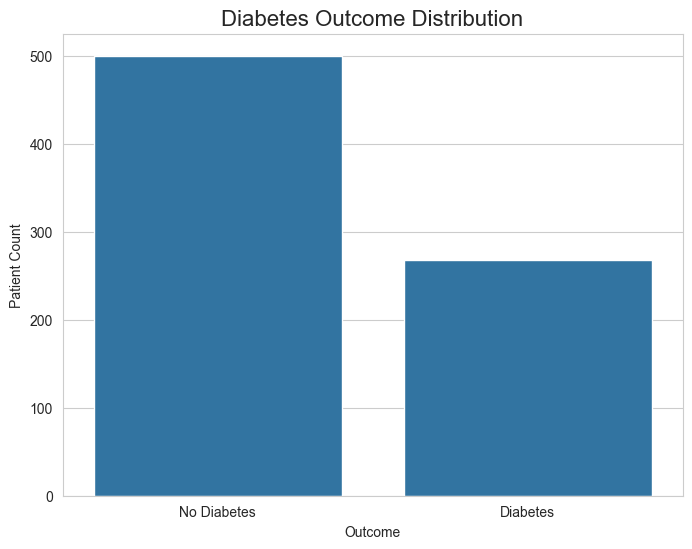

In [28]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Outcome',
    data=df
)

plt.title(
    "Diabetes Outcome Distribution",
    fontsize=16
)

plt.xlabel("Outcome")
plt.ylabel("Patient Count")

plt.xticks(
    [0,1],
    ['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/diabetes_outcome_distribution.png",
    bbox_inches='tight'
)

plt.show()

## Insight

This visualization shows the distribution of diabetes cases in the dataset. Understanding class balance is important for identifying disease prevalence and supporting healthcare decision-making.

# Visualization 2: Glucose Level and Diabetes Risk

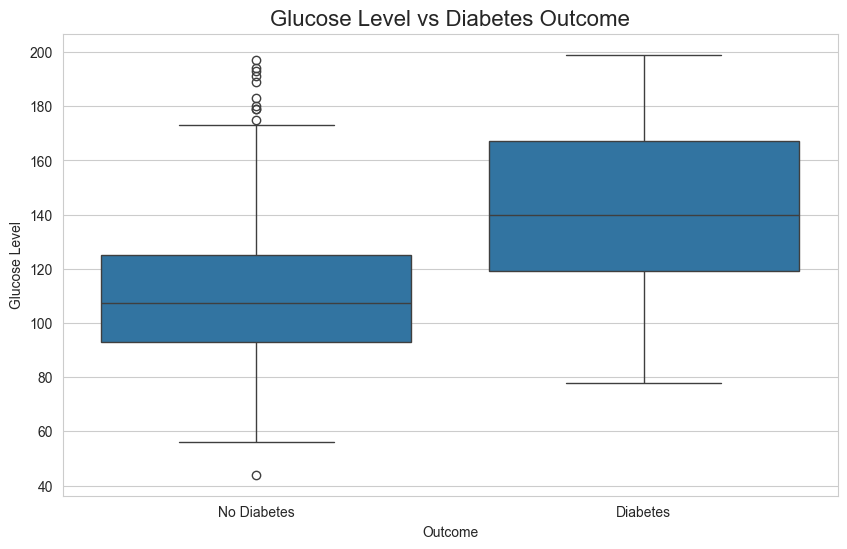

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title(
    "Glucose Level vs Diabetes Outcome",
    fontsize=16
)

plt.xlabel("Outcome")
plt.ylabel("Glucose Level")

plt.xticks(
    [0,1],
    ['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/glucose_vs_diabetes.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Patients diagnosed with diabetes generally exhibit higher glucose levels compared to non-diabetic individuals. This suggests glucose level is a strong indicator of diabetes risk.

# Visualization 3: BMI Category Distribution

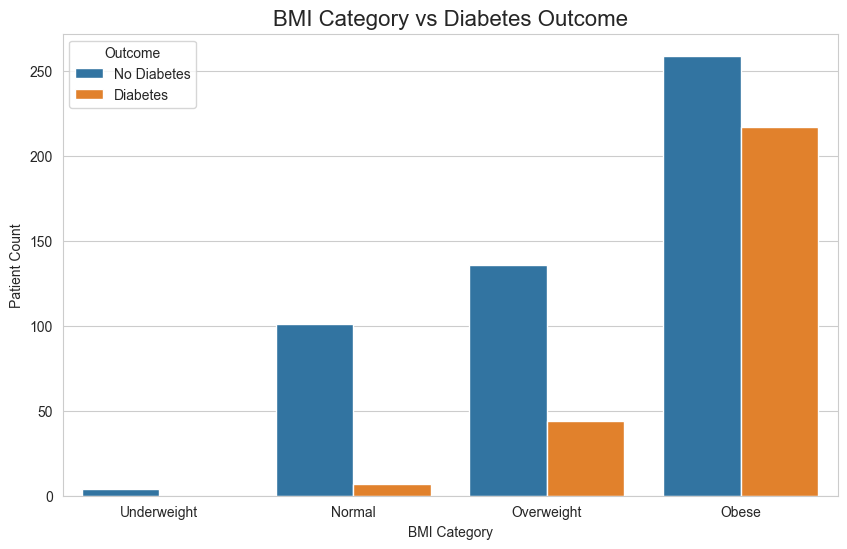

In [30]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='BMI_Category',
    hue='Outcome',
    data=df
)

plt.title(
    "BMI Category vs Diabetes Outcome",
    fontsize=16
)

plt.xlabel("BMI Category")
plt.ylabel("Patient Count")

plt.legend(
    title="Outcome",
    labels=['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/bmi_category_analysis.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Higher BMI categories, particularly overweight and obese patients, appear to demonstrate increased diabetes occurrence, suggesting obesity may contribute significantly to diabetes risk.

# Visualization 4: Age Group and Diabetes Outcome

This visualization examines how diabetes prevalence varies across different age groups and helps identify patient populations that may be more vulnerable to diabetes risk.

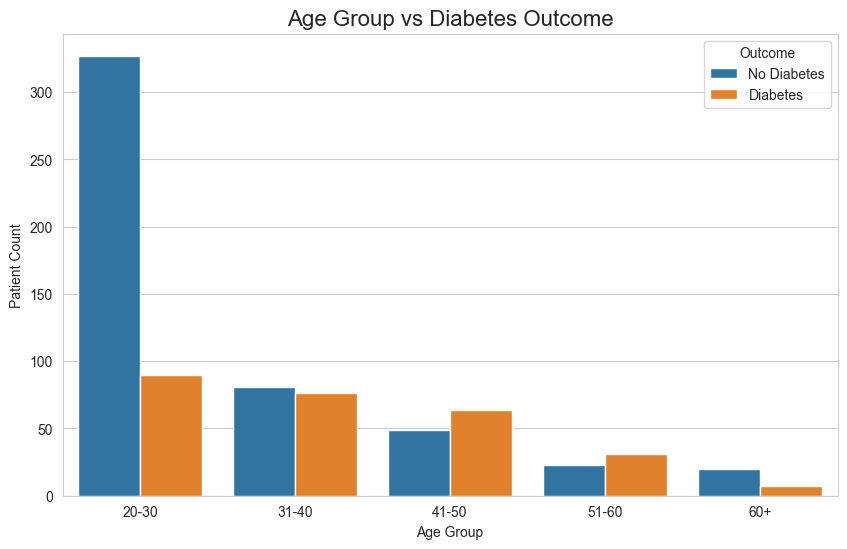

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Age_Group',
    hue='Outcome',
    data=df
)

plt.title(
    "Age Group vs Diabetes Outcome",
    fontsize=16
)

plt.xlabel("Age Group")
plt.ylabel("Patient Count")

plt.legend(
    title="Outcome",
    labels=['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/age_group_analysis.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Older age groups demonstrate a greater prevalence of diabetes, indicating age may be an important contributing factor to diabetes risk.

# Visualization 5: Correlation Between Healthcare Variables

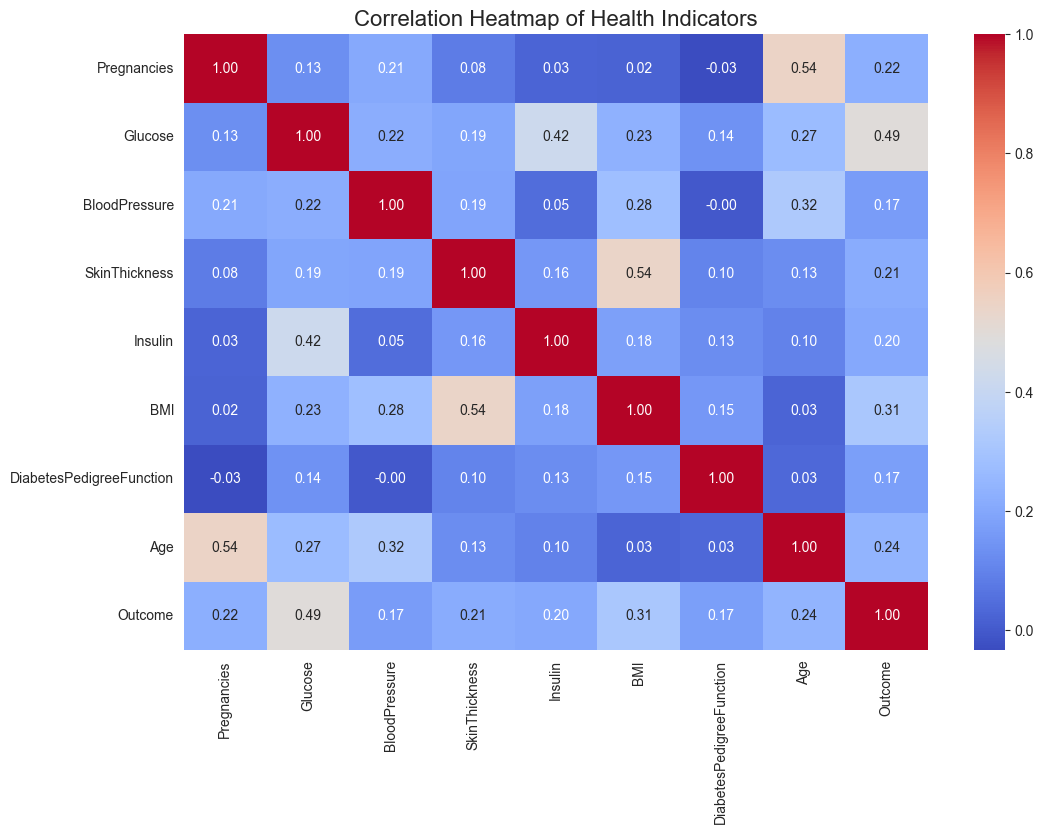

In [32]:
plt.figure(figsize=(12,8))

corr = df.corr(
    numeric_only=True
)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "Correlation Heatmap of Health Indicators",
    fontsize=16
)

# Save Image
plt.savefig(
    "../images/correlation_heatmap.png",
    bbox_inches='tight'
)

plt.show()

## Insight

The heatmap reveals relationships among medical indicators and diabetes outcome. Strong positive correlations may indicate variables that significantly influence diabetes risk.

# Advanced Statistical Analysis

This section compares healthcare indicators between diabetic and non-diabetic patients to identify major contributing risk factors.

In [33]:
print("="*60)
print("HEALTH INDICATOR COMPARISON")
print("="*60)

health_metrics = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'Age'
]

comparison = df.groupby(
    'Outcome'
)[health_metrics].mean()

print(comparison)

HEALTH INDICATOR COMPARISON
            Glucose  BloodPressure  SkinThickness     Insulin        BMI  \
Outcome                                                                    
0        110.682000      70.920000      27.726000  127.792000  30.885600   
1        142.130597      75.123134      31.686567  164.701493  35.383582   

               Age  
Outcome             
0        31.190000  
1        37.067164  


# Visualization 6: Average Health Indicators by Diabetes Outcome

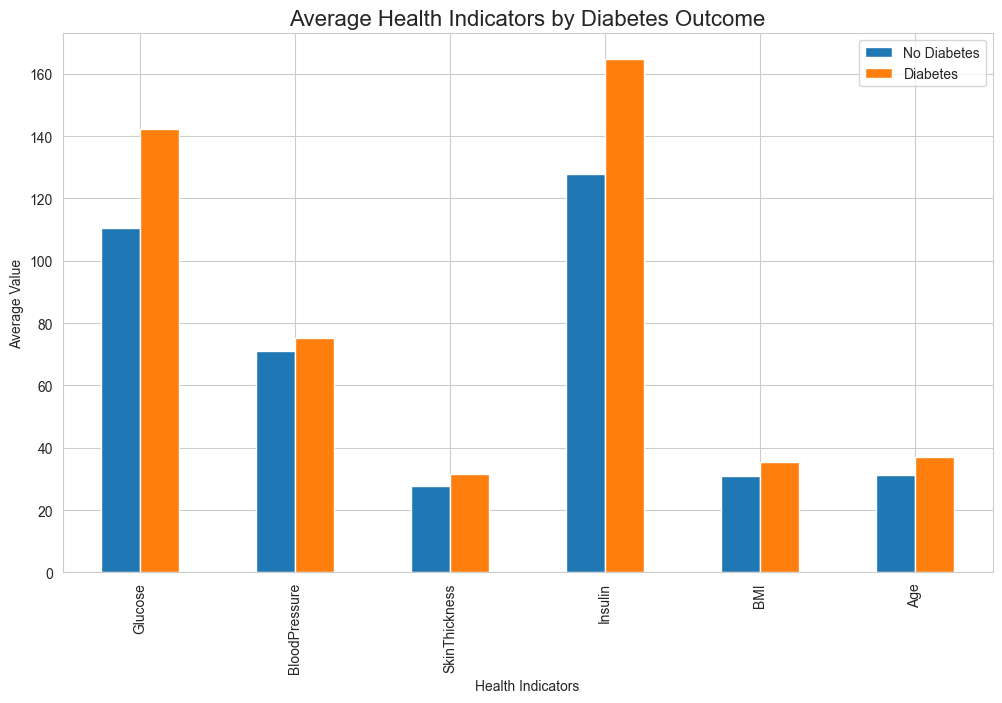

In [34]:
comparison.T.plot(
    kind='bar',
    figsize=(12,7)
)

plt.title(
    "Average Health Indicators by Diabetes Outcome",
    fontsize=16
)

plt.xlabel("Health Indicators")
plt.ylabel("Average Value")

plt.legend(
    ['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/health_indicator_comparison.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Diabetic patients generally demonstrate higher average glucose levels, BMI, insulin levels, and age compared to non-diabetic patients. This suggests these indicators may significantly contribute to diabetes risk.

# Visualization 7: Glucose Distribution Analysis

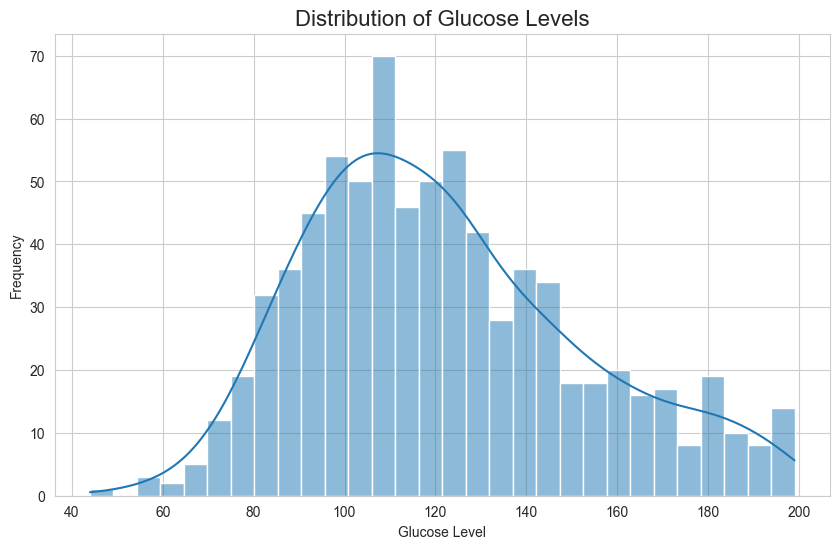

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Glucose'],
    kde=True,
    bins=30
)

plt.title(
    "Distribution of Glucose Levels",
    fontsize=16
)

plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

# Save Image
plt.savefig(
    "../images/glucose_distribution.png",
    bbox_inches='tight'
)

plt.show()

## Insight

The glucose distribution reveals concentration patterns among patients and helps identify whether elevated glucose levels are common within the population.

# Visualization 8: BMI vs Glucose Relationship

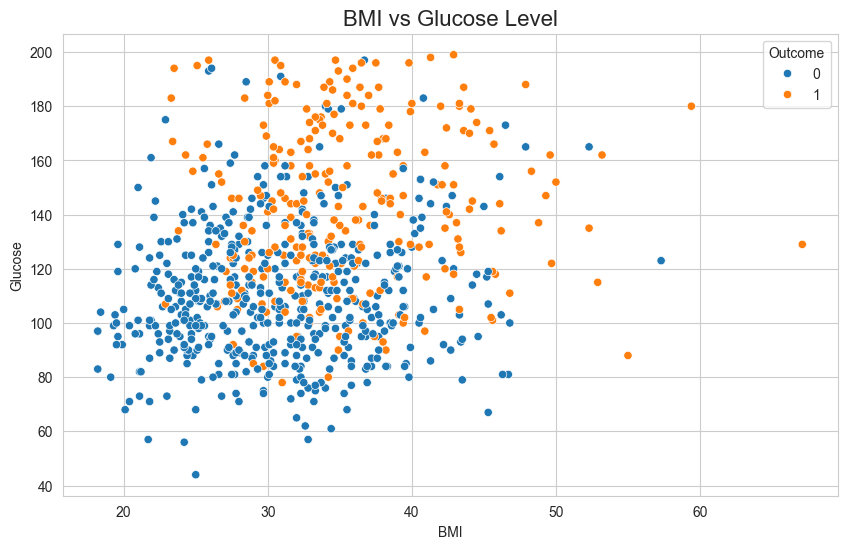

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='BMI',
    y='Glucose',
    hue='Outcome',
    data=df
)

plt.title(
    "BMI vs Glucose Level",
    fontsize=16
)

plt.xlabel("BMI")
plt.ylabel("Glucose")

# Save Image
plt.savefig(
    "../images/bmi_vs_glucose.png",
    bbox_inches='tight'
)

plt.show()

## Insight

This visualization helps explore whether increased BMI is associated with elevated glucose levels and diabetes occurrence.

# Correlation Analysis with Diabetes Outcome

In [37]:
correlation = df.corr(
    numeric_only=True
)['Outcome'].sort_values(
    ascending=False
)

print(correlation)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


# High Risk Patient Analysis

This section identifies characteristics associated with patients who demonstrate a higher probability of diabetes risk.

In [38]:
diabetic_patients = df[
    df['Outcome'] == 1
]

print("="*60)
print("HIGH RISK PATIENT CHARACTERISTICS")
print("="*60)

print(diabetic_patients.describe())

HIGH RISK PATIENT CHARACTERISTICS
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   268.000000  268.000000     268.000000     268.000000  268.000000   
mean      4.865672  142.130597      75.123134      31.686567  164.701493   
std       3.741239   29.568839      11.951672       8.662994  100.932249   
min       0.000000   78.000000      30.000000       7.000000   14.000000   
25%       1.750000  119.000000      68.000000      29.000000  125.000000   
50%       4.000000  140.000000      74.000000      29.000000  125.000000   
75%       8.000000  167.000000      82.000000      36.000000  167.250000   
max      17.000000  199.000000     114.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  Outcome  
count  268.000000                268.000000  268.000000    268.0  
mean    35.383582                  0.550500   37.067164      1.0  
std      6.595603                  0.372354   10.968254      0.0  
min     22.90

# Visualization 9: Diabetes Risk Across Age Groups

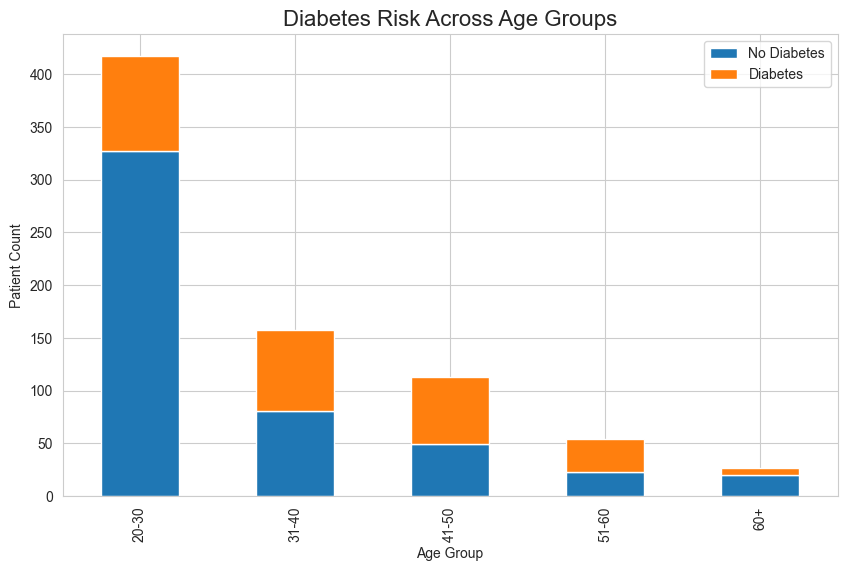

In [39]:
age_risk = pd.crosstab(
    df['Age_Group'],
    df['Outcome']
)

age_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Diabetes Risk Across Age Groups",
    fontsize=16
)

plt.xlabel("Age Group")
plt.ylabel("Patient Count")

plt.legend(
    ['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/age_group_risk.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Certain age groups demonstrate greater diabetes prevalence, suggesting age-related health deterioration may contribute to increased diabetes risk.

# Visualization 10: BMI Risk Analysis

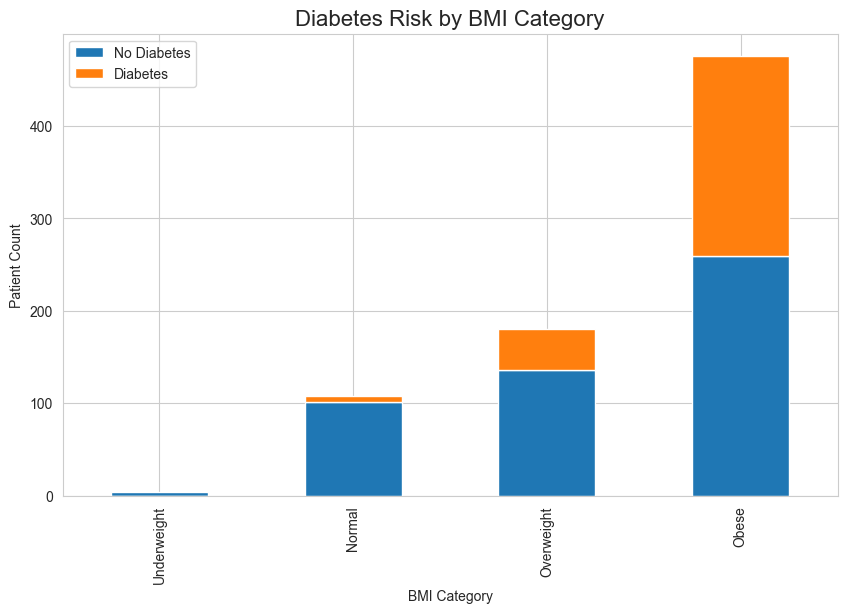

In [40]:
bmi_risk = pd.crosstab(
    df['BMI_Category'],
    df['Outcome']
)

bmi_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Diabetes Risk by BMI Category",
    fontsize=16
)

plt.xlabel("BMI Category")
plt.ylabel("Patient Count")

plt.legend(
    ['No Diabetes','Diabetes']
)

# Save Image
plt.savefig(
    "../images/bmi_risk_analysis.png",
    bbox_inches='tight'
)

plt.show()

## Insight

Overweight and obese patients demonstrate a comparatively greater prevalence of diabetes, reinforcing the association between excess body weight and diabetes risk.

<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 38px 42px;
            border-radius: 18px;
            border: 1px solid #7c3aed;
            width: 85%;
            margin: auto;
            box-shadow:0px 0px 18px rgba(124,58,237,0.25);">

<h2 style="text-align:center; color:#c084fc;">
🔬 Research Findings
</h2>

<p style="color:#cbd5e1; text-align:center; font-size:1.05em;">
Based on the analysis, the following findings were observed:
</p>

<table style="width:100%; border-collapse:collapse; color:#e2e8f0; margin-top:20px;">

<tr style="background-color: rgba(124,58,237,0.15);">
<th style="padding:12px; border:1px solid #7c3aed;">
Research Question
</th>

<th style="padding:12px; border:1px solid #7c3aed;">
Key Finding
</th>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>1. Major Health Indicators</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
Glucose level, BMI, age, and insulin levels demonstrated stronger relationships with diabetes occurrence.
</td>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>2. Glucose Level Impact</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
Patients diagnosed with diabetes generally exhibited significantly higher glucose levels.
</td>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>3. BMI Association</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
Overweight and obese patients showed greater diabetes prevalence.
</td>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>4. Age Influence</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
Older patient groups demonstrated comparatively higher diabetes occurrence.
</td>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>5. Strong Variable Correlation</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
Glucose demonstrated the strongest correlation with diabetes outcome, followed by BMI and age-related factors.
</td>
</tr>

<tr>
<td style="padding:12px; border:1px solid #7c3aed;">
<b>6. Preventive Screening</b>
</td>

<td style="padding:12px; border:1px solid #7c3aed;">
High-risk patient groups can be identified through glucose, BMI, and age-based monitoring.
</td>
</tr>

</table>

</div>

<br>

<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 38px 42px;
            border-radius: 18px;
            border: 1px solid #7c3aed;
            width: 85%;
            margin: auto;
            box-shadow:0px 0px 18px rgba(124,58,237,0.25);">

<h2 style="text-align:center; color:#c084fc;">
💡 Healthcare Recommendations
</h2>

<p style="color:#cbd5e1; text-align:center; font-size:1.05em;">
Based on the findings, the following healthcare recommendations are proposed:
</p>

<ol style="color:#e2e8f0; line-height:2em; font-size:1.05em;">

<li>
<b>Prioritize early diabetes screening</b> for high-risk individuals with elevated glucose and BMI levels.
</li>

<li>
<b>Healthcare awareness programs</b> should target overweight and obese populations.
</li>

<li>
<b>Routine monitoring</b> should be prioritized for older individuals due to higher diabetes prevalence.
</li>

<li>
<b>Healthcare institutions</b> should leverage patient analytics for early intervention strategies.
</li>

<li>
<b>Lifestyle modification programs</b> focusing on diet and physical activity may help reduce diabetes prevalence.
</li>

</ol>

</div>

<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 38px 42px;
            border-radius: 18px;
            border: 1px solid #7c3aed;
            width: 85%;
            margin: auto;
            box-shadow:0px 0px 18px rgba(124,58,237,0.25);">

<h2 style="text-align:center; color:#c084fc;">
⚠️ Limitations
</h2>

<p style="color:#cbd5e1; text-align:center; font-size:1.05em;">
This study has several limitations that should be considered while interpreting the findings:
</p>

<ul style="color:#e2e8f0; line-height:2em; font-size:1.05em;">

<li>
The dataset size is relatively limited, which may affect broader generalization.
</li>

<li>
Additional demographic variables such as gender, diet, physical activity, and lifestyle habits were unavailable.
</li>

<li>
Correlation analysis identifies relationships between variables but does not establish direct causation.
</li>

<li>
Medical diagnosis may depend on additional healthcare indicators beyond the selected variables in the dataset.
</li>

</ul>

</div>

<br>

<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 38px 42px;
            border-radius: 18px;
            border: 1px solid #7c3aed;
            width: 85%;
            margin: auto;
            box-shadow:0px 0px 18px rgba(124,58,237,0.25);">

<h2 style="text-align:center; color:#c084fc;">
🚀 Future Scope
</h2>

<p style="color:#cbd5e1; text-align:center; font-size:1.05em;">
Future research and improvements may include:
</p>

<ul style="color:#e2e8f0; line-height:2em; font-size:1.05em;">

<li>
Development of <b>machine learning prediction models</b> for early diabetes detection.
</li>

<li>
Analysis using <b>larger and more diverse healthcare datasets</b> to improve generalizability.
</li>

<li>
Integration of <b>demographic and lifestyle variables</b> such as diet, exercise, smoking, and sleep patterns.
</li>

<li>
Implementation of <b>real-time healthcare monitoring systems</b> for patient risk assessment.
</li>

<li>
Expansion toward <b>predictive healthcare analytics</b> for preventive disease management.
</li>

</ul>

</div>

<br>

<div style="background: linear-gradient(135deg, #0a0a1a, #1a0533, #0d1b2a);
            padding: 40px 45px;
            border-radius: 18px;
            border: 1px solid #7c3aed;
            width: 85%;
            margin: auto;
            box-shadow:0px 0px 18px rgba(124,58,237,0.25);">

<h2 style="text-align:center; color:#c084fc;">
🏁 Conclusion
</h2>

<p style="color:#e2e8f0; line-height:2em; font-size:1.05em; text-align:justify;">

This project conducted an <b>advanced healthcare analytics study</b> to identify the major health indicators influencing diabetes risk. Through <b>data exploration, preprocessing, feature engineering, statistical analysis, and visualization techniques</b>, meaningful relationships among patient healthcare variables were identified.

The analysis revealed that <b>glucose level, BMI, age, and insulin-related indicators</b> contribute significantly to diabetes occurrence. Higher diabetes prevalence was observed among <b>overweight and older patient groups</b>, reinforcing the importance of preventive healthcare monitoring.

Furthermore, correlation and visualization analyses highlighted strong relationships among healthcare indicators, demonstrating the growing role of <b>data analytics in disease understanding, risk profiling, and preventive healthcare decision-making.</b>

Overall, this project highlights how healthcare analytics can support <b>early screening, patient risk assessment, and informed healthcare strategies</b> for better diabetes prevention and management.

</p>

<hr style="border:1px solid #7c3aed; width:65%; margin-top:25px;">

<p style="text-align:center; color:#94a3b8;">
📌 <b>Project:</b> ShadowFox Internship — Task 3 (Advanced Level) <br>
📦 <b>Dataset:</b> Pima Indians Diabetes Dataset (UCI / Kaggle)
</p>

</div>